In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [82]:
url_listing_berlin = "https://raw.githubusercontent.com/Nill2nn/Statistical-Programming/refs/heads/Nill2nn-patch-excel/listings_berlin.csv"
listings_berlin = pd.read_csv(url_listing_berlin)

In [83]:
def clean_price(price_str):
    if pd.isna(price_str):
        return None
    if isinstance(price_str, str):
        return float(price_str.replace('$', '').replace(',', ''))
    return float(price_str)

listings_berlin['price'] = listings_berlin['price'].apply(clean_price)

In [84]:
def clean_baths(bathroom):
    if pd.isna(bathroom):
        return None

    bathroom = str(bathroom).lower()

    if 'half' in bathroom:
        return 0.5
    else:
        numpart = bathroom.split(' ')[0]
        return float(numpart)


listings_berlin['bathrooms_text'] = listings_berlin['bathrooms_text'].apply(clean_baths)

In [85]:
#Task1
listings_berlin = listings_berlin.dropna()
listings_berlin = listings_berlin[listings_berlin['price'] > 0]


In [86]:
Y = np.log(listings_berlin['price'])
X = listings_berlin[["bedrooms", "bathrooms_text", "review_scores_rating", "availability_365","reviews_per_month", "accommodates", "instant_bookable", "room_type"]]


In [87]:
X = pd.get_dummies(X, columns=['instant_bookable', 'room_type'], drop_first=True).astype(float)

In [88]:
print(f'Sample size: {len(X)} observations')
X['instant_bookable_t'].unique()
print(X.dtypes)

Sample size: 6482 observations
bedrooms                  float64
bathrooms_text            float64
review_scores_rating      float64
availability_365          float64
reviews_per_month         float64
accommodates              float64
instant_bookable_t        float64
room_type_Hotel room      float64
room_type_Private room    float64
room_type_Shared room     float64
dtype: object


In [112]:
#Task2
Xc = sm.add_constant(X)
ols_model = sm.OLS(Y, Xc)
ols_model = ols_model.fit(cov_type = 'HC3')
print(ols_model.summary())
'''The model including review variables has a higher R², suggesting that reviews help explain variation in prices. However, the sample size decreases substantially because listings without reviews are excluded.'''

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.447
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     473.8
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:19:59   Log-Likelihood:                -4310.5
No. Observations:                6482   AIC:                             8643.
Df Residuals:                    6471   BIC:                             8718.
Df Model:                          10                                         
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      3

'The model including review variables has a higher R², suggesting that reviews help explain variation in prices. However, the sample size decreases substantially because listings without reviews are excluded.'

In [90]:
'''The largest positive coefficients are for hotel rooms, instant-bookable listings, and number of bedrooms, indicating that these features are associated with higher Airbnb prices in Berlin. In particular:
1. Room_type_Hotel room (dummy variable) are priced about 0.53 units higher than entire homes/apartments on average. 
2. Instant bookable (dummy variable) listings have prices that are about 23.4% higher than other ones, holding all other variables constant.
3. Each additional bedroom increases the listing price by 12.6% holding other variables constant.
The coefficient for shared rooms is strongly negative, indicating that shared accommodations are substantially cheaper than entire homes or apartments due to the lower level of privacy offered.
The R squared value implies that the OLS model explains about 44.7% of the Airbnb price variations in Berlin. We set up 2 models that include different variables. 
The model including review variables has a higher R^2, suggesting that reviews explain variations in price'''

'The largest positive coefficients are for hotel rooms, instant-bookable listings, and number of bedrooms, indicating that these features are associated with higher Airbnb prices in Berlin. In particular:\n1. Room_type_Hotel room (dummy variable) are priced about 0.53 units higher than entire homes/apartments on average. \n2. Instant bookable (dummy variable) listings have prices that are about 23.4% higher than other ones, holding all other variables constant.\n3. Each additional bedroom increases the listing price by 12.6% holding other variables constant.\nThe coefficient for shared rooms is strongly negative, indicating that shared accommodations are substantially cheaper than entire homes or apartments due to the lower level of privacy offered.\nThe R squared value implies that the OLS model explains about 44.7% of the Airbnb price variations in Berlin. We set up 2 models that include different variables. \nThe model including review variables has a higher R^2, suggesting that rev

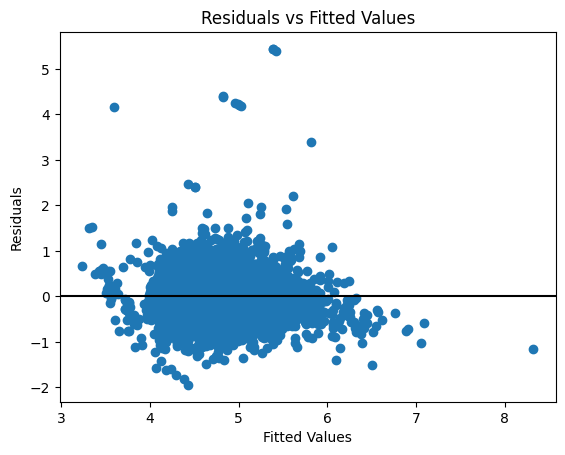

In [114]:
#Task3
#need to assign variables with residual, fitted values. True values are Y
fitted = ols.fittedvalues
residuals = ols.resid
#residual-vs-fitted-values plot
plt.scatter(ols.fittedvalues, ols.resid)
plt.axhline(0, color='black')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

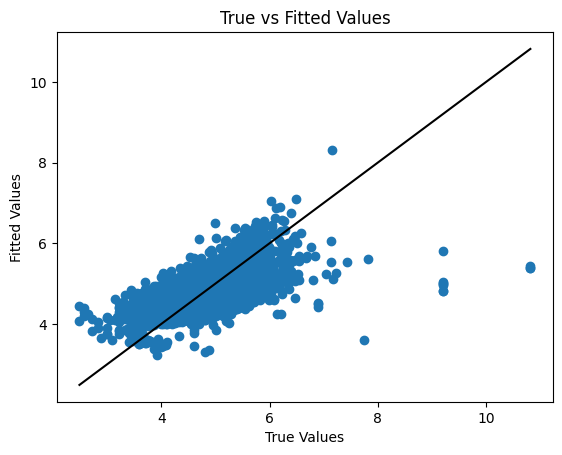

In [115]:
#True-fitted plot
plt.scatter(Y, ols.fittedvalues)
plt.plot([Y.min(), Y.max()],
         [Y.min(), Y.max()],
         color='black')
plt.xlabel("True Values")
plt.ylabel("Fitted Values")
plt.title("True vs Fitted Values")
plt.show()


In [93]:
'''The residual-vs-fitted plot shows that residuals are roughly centered around zero and randomly scattered without a clear systematic pattern. This suggests that the linear specification of the model is appropriate. However, a few outliers and slightly larger dispersion at higher fitted values may indicate mild heteroskedasticity.
The true-vs-fitted plot shows that predicted values follow the actual prices closely, with many observations located near the 45-degree line. This indicates that the model captures a substantial portion of the variation in Airbnb prices, although some dispersion remains.
'''

'The residual-vs-fitted plot shows that residuals are roughly centered around zero and randomly scattered without a clear systematic pattern. This suggests that the linear specification of the model is appropriate. However, a few outliers and slightly larger dispersion at higher fitted values may indicate mild heteroskedasticity.\nThe true-vs-fitted plot shows that predicted values follow the actual prices closely, with many observations located near the 45-degree line. This indicates that the model captures a substantial portion of the variation in Airbnb prices, although some dispersion remains.\n'

In [94]:
#Task4
#we define a function ridge_estimate that matches the given formula
def ridge_estimate(X, Y, lam):
    I = np.eye(X.shape[1])
    beta = np.linalg.inv(X.T @ X + lam * I) @ X.T @ Y
    return beta

In [95]:
for lam in [0.01, 1, 100]:
    beta = ridge_estimate(X, Y, lam)
    norm = np.linalg.norm(beta, 2)
    print('Lambda:', lam)
    print('L2 norm:', norm)

Lambda: 0.01
L2 norm: 1.477169202968384
Lambda: 1
L2 norm: 1.4666186917162836
Lambda: 100
L2 norm: 1.0675614634092474


In [96]:
'''The greater the parameter of lambda - the greater becomes the penalty and more coefficients will shrink towards 0. That's why L2 norm is the smallest given the largest parameter of lambda, in this case it is 100 '''

"The greater the parameter of lambda - the greater becomes the penalty and more coefficients will shrink towards 0. That's why L2 norm is the smallest given the largest parameter of lambda, in this case it is 100 "

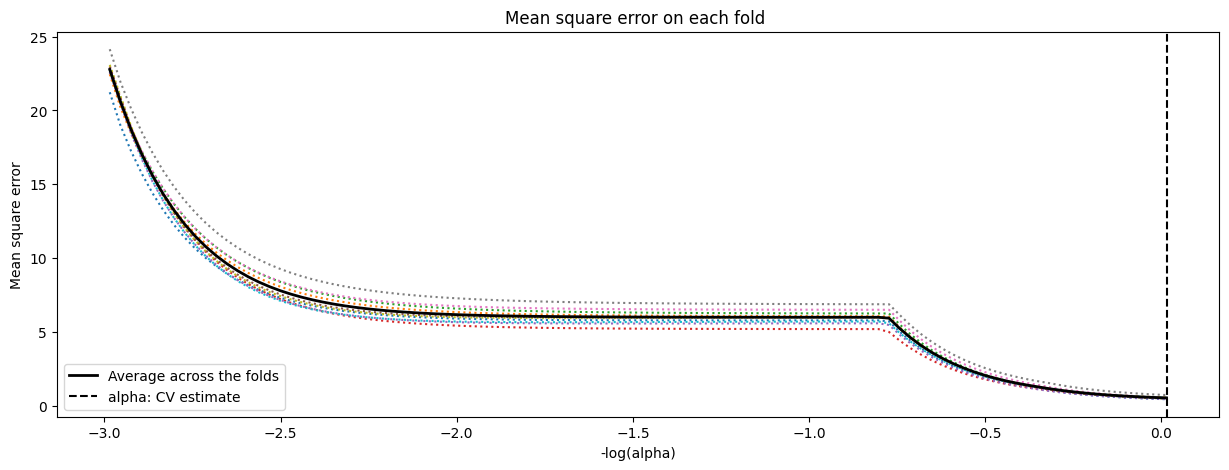

In [97]:
#task5
from sklearn import linear_model
lassocv_reg = linear_model.LassoCV(cv=10,fit_intercept = False)
model = lassocv_reg.fit(X, Y)

m_log_alphas = -np.log10(model.alphas_)
plt.figure(1,figsize=(15,5))
plt.plot(m_log_alphas, model.mse_path_, ':')
plt.plot(m_log_alphas, model.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(-np.log10(model.alpha_), linestyle='--', color='k',
            label='alpha: CV estimate')
plt.legend()
plt.xlabel('-log(alpha)')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold ')

plt.axis('tight')
plt.show()

In [98]:
print("Selected alpha:", model.alpha_)

for name, coef in zip(X.columns, model.coef_):
    if coef == 0:
        print(name, coef)


Selected alpha: 0.9659542672092013
bedrooms 0.0
bathrooms_text 0.0
reviews_per_month 0.0
instant_bookable_t 0.0
room_type_Hotel room 0.0
room_type_Private room -0.0
room_type_Shared room 0.0


In [99]:
'''These features receive 0 coefficients.
The LASSO model selects the regularization parameter α using cross-validation. After fitting the model, some coefficients are shrunk to exactly zero, meaning those features are excluded from the model. This indicates that LASSO performs feature selection. In contrast, OLS includes all variables without regularization, and Ridge regression shrinks coefficients toward zero but does not set them exactly to zero. Therefore, LASSO results in a smaller subset of predictors compared to OLS and Ridge.'''


'These features receive 0 coefficients.\nThe LASSO model selects the regularization parameter α using cross-validation. After fitting the model, some coefficients are shrunk to exactly zero, meaning those features are excluded from the model. This indicates that LASSO performs feature selection. In contrast, OLS includes all variables without regularization, and Ridge regression shrinks coefficients toward zero but does not set them exactly to zero. Therefore, LASSO results in a smaller subset of predictors compared to OLS and Ridge.'

In [100]:
#task6
#we are doing a split into training and test sets by applying train_test_split function
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 77)

In [116]:
#we splitted the datat into test and training sets and now we perform the 3 regressions on base of these samples
#we start with OLS 
#before that we need to import from scikit metrics the mean squared error
# Important OUT-OF-SAMPLE means that we use test data and not the data we used to train the model
from sklearn.metrics import mean_squared_error
X_train_c = sm.add_constant(X_train)
X_test_c = sm.add_constant(X_test)
ols_2 = sm.OLS(Y_train, X_train_c)
ols_2 = ols_2.fit(cov_type = 'HC3')
y_pred1 = ols_2.predict(X_test_c)
rmse_1 = np.sqrt(mean_squared_error(Y_test, y_pred1))
print("OLS RMSE:", rmse_1)

#ols.summary()


OLS RMSE: 0.44958900420893155


In [117]:
#we proceed with ridge
ridgecv_reg = linear_model.RidgeCV(cv=10,fit_intercept = False)
ridge_model = ridgecv_reg.fit(X_train_c, Y_train)
y_pred2 = ridge_model.predict(X_test_c)
rmse_2 = np.sqrt(mean_squared_error(Y_test, y_pred2))
print("Ridge RMSE:", rmse_2)

Ridge RMSE: 0.44958019006483235


In [118]:
#finally we go to lasso
lassocv_reg = linear_model.LassoCV(cv=10,fit_intercept = False)
lasso_model = lassocv_reg.fit(X_train_c, Y_train)
y_pred3 = lasso_model.predict(X_test_c)
rmse_3 = np.sqrt(mean_squared_error(Y_test, y_pred3))
print("LASSO RMSE:", rmse_3)

LASSO RMSE: 0.6895870021732522


In [104]:
'''For this task out-of-sample RMSE was computed using the train-tast split for all 3 models. 
OLS and Ridge have almost identical RMSE values (around 0.45), meaning they perform similarly well. Ridge performs slightly better, but the difference is very small.
In contrast, LASSO has a much higher RMSE (around 0.69), indicating worse prediction performance. This is likely because LASSO removes some variables, which reduces the model’s ability to capture all relevant information.
Overall, Ridge performs best, but OLS is nearly as good, while LASSO performs worst.'''

'For this task out-of-sample RMSE was computed using the train-tast split for all 3 models. \nOLS and Ridge have almost identical RMSE values (around 0.45), meaning they perform similarly well. Ridge performs slightly better, but the difference is very small.\nIn contrast, LASSO has a much higher RMSE (around 0.69), indicating worse prediction performance. This is likely because LASSO removes some variables, which reduces the model’s ability to capture all relevant information.\nOverall, Ridge performs best, but OLS is nearly as good, while LASSO performs worst.'

In [ ]:
#Task8
#we reestimate model from task2 using LAD
from statsmodels.regression.quantile_regression import QuantReg
qr = sm.QuantReg(Y, Xc)
med = qr.fit(q = 0.5)
med.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         QuantReg Regression Results                          
==============================================================================
Dep. Variable:                  price   Pseudo R-squared:               0.2971
Model:                       QuantReg   Bandwidth:                      0.1061
Method:                 Least Squares   Sparsity:                        1.022
Date:                Tue, 17 Mar 2026   No. Observations:                 6482
Time:                        17:23:26   Df Residuals:                     6471
                                        Df Model:                           10
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      3.6630      0.091     40.378      0.000       3.485       3.841
bedrooms                   0.1393      0.011     12.532      0.000       0.118       0.161
bathrooms_text             0.0790      0.015      5.127      0.000       0.049       0.109
review_scores_rating       0.1164      0.018      6.385      0.000       0.081       0.152
availability_365           0.0002   5.46e-05      2.949      0.003     5.4e-05       0.000
reviews_per_month         -0.0163      0.003     -5.675      0.000      -0.022      -0.011
accommodates               0.0750      0.004     16.979      0.000       0.066       0.084
instant_bookable_t         0.1968      0.014     13.734      0.000       0.169       0.225
room_type_Hotel room       0.4213      0.058      7.324      0.000       0.309       0.534
room_type_Private room    -0.4082      0.016    -25.863      0.000      -0.439      -0.377
room_type_Shared room     -1.0938      0.058    -18.729      0.000      -1.208      -0.979
==========================================================================================

The condition number is large, 3.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
'''The LAD and OLS results are very similar, indicating robust relationships. 
The largest changes occur for review scores, hotel room type, and instant booking,suggesting that these variables are somewhat sensitive to outliers. 
However, the signs of all coefficients remain unchanged and all variables remain statistically significant, so the overall conclusions do not change. 
LAD results confirm the findings of OLS and are not that much influenced by extreme observations'''

In [ ]:
#Task9
